In [25]:
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
df = pd.read_csv("soja_brasil.csv")

In [4]:
print(df)

    Ano   Area_ha  Producao_t  Produtividade_kg_ha
0  2015  32000000    96600000                 3019
1  2016  33300000    95500000                 2868
2  2017  33900000   114000000                 3363
3  2018  34771690   117887672                 3390
4  2019  35800000   120900000                 3377
5  2020  37000000   124800000                 3373
6  2021  38600000   135900000                 3521
7  2022  41000000   124000000                 3024
8  2023  44447552   152144238                 3423
9  2024  46200000   144500000                 3128


In [5]:
print("\nEstatísticas:")
print(df.describe())


Estatísticas:
              Ano       Area_ha    Producao_t  Produtividade_kg_ha
count    10.00000  1.000000e+01  1.000000e+01            10.000000
mean   2019.50000  3.770192e+07  1.226232e+08          3248.600000
std       3.02765  4.812535e+06  1.839572e+07           219.145411
min    2015.00000  3.200000e+07  9.550000e+07          2868.000000
25%    2017.25000  3.411792e+07  1.149719e+08          3050.000000
50%    2019.50000  3.640000e+07  1.224500e+08          3368.000000
75%    2021.75000  4.040000e+07  1.331250e+08          3386.750000
max    2024.00000  4.620000e+07  1.521442e+08          3521.000000


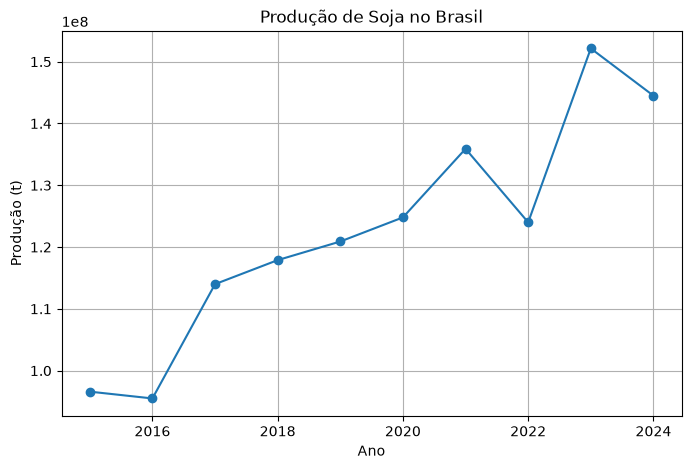

In [6]:
plt.figure(figsize=(8,5))
plt.plot(df["Ano"], df["Producao_t"], marker="o")
plt.title("Produção de Soja no Brasil")
plt.xlabel("Ano")
plt.ylabel("Produção (t)")
plt.grid()
plt.show()

In [13]:
import matplotlib.pyplot as plt

In [26]:
df = pd.read_csv("soja_estados.csv")

In [27]:
print("\n=== PRODUÇÃO DE SOJA POR ESTADO ===")
print(df)


=== PRODUÇÃO DE SOJA POR ESTADO ===
               Estado Sigla   Area_ha  Producao_t  Produtividade_kg_ha
0         Mato Grosso    MT  12500000    50000000                 4000
1              Paraná    PR   5800000    22000000                 3793
2   Rio Grande do Sul    RS   6700000    21000000                 3134
3               Goiás    GO   4700000    18000000                 3830
4  Mato Grosso do Sul    MS   4300000    15000000                 3488
5        Minas Gerais    MG   2200000     8500000                 3864
6               Bahia    BA   2100000     7800000                 3714
7           São Paulo    SP   1200000     4500000                 3750
8            Maranhão    MA   1100000     3900000                 3545
9           Tocantins    TO   1000000     3600000                 3600


In [28]:
import sys
!{sys.executable} -m pip install plotly

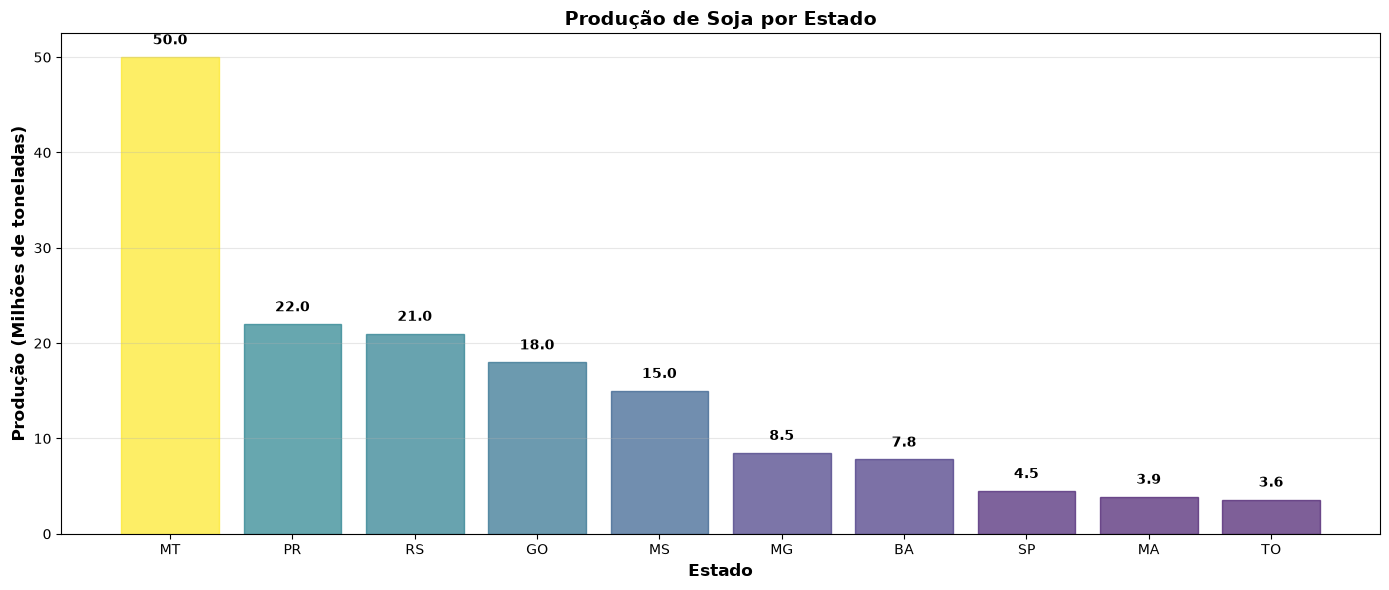

In [32]:
# Usar dados agregados por estado
df_agg = df.groupby("Sigla").agg({
    "Producao_t": "sum",
    "Area_ha": "sum",
    "Produtividade_kg_ha": "mean",
    "Estado": "first"
}).reset_index()

# Ordenar por produção
df_agg = df_agg.sort_values("Producao_t", ascending=False)

# Gráfico de barras com matplotlib (mais simples e funcional)
plt.figure(figsize=(14, 6))
bars = plt.bar(df_agg["Sigla"], df_agg["Producao_t"] / 1e6, color='steelblue', edgecolor='navy', alpha=0.7)

# Adicionar cores gradientes
colors = plt.cm.viridis(df_agg["Producao_t"] / df_agg["Producao_t"].max())
for bar, color in zip(bars, colors):
    bar.set_color(color)

plt.xlabel("Estado", fontsize=12, fontweight='bold')
plt.ylabel("Produção (Milhões de toneladas)", fontsize=12, fontweight='bold')
plt.title("Produção de Soja por Estado", fontsize=14, fontweight='bold')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

# Adicionar valores nas barras
for i, (sigla, producao) in enumerate(zip(df_agg["Sigla"], df_agg["Producao_t"] / 1e6)):
    plt.text(i, producao + 1, f'{producao:.1f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()